Imports

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

import joblib
import warnings
warnings.filterwarnings('ignore')

Load Data

In [43]:
train_df = pd.read_csv('../data/train_motion_data.csv')
test_df = pd.read_csv('../data/test_motion_data.csv')

print("Training Data Shape:", train_df.shape)
print("Testing Data Shape:", test_df.shape)
train_df.head()

Training Data Shape: (3644, 8)
Testing Data Shape: (3084, 8)


,AccX,AccY,AccZ,GyroX,GyroY,GyroZ,Class,Timestamp
0,0.000000,0.000000,0.000000,0.059407,-0.174707,0.101938,NORMAL,3581629
1,-1.624864,-1.082492,-0.204183,-0.028558,0.051313,0.135536,NORMAL,3581630
2,-0.594660,-0.122410,0.220502,-0.019395,-0.029322,0.087888,NORMAL,3581630
3,0.738478,-0.228456,0.667732,0.069791,-0.029932,0.054902,NORMAL,3581631
4,0.101741,0.777568,-0.066730,0.030696,-0.003665,0.054902,NORMAL,3581631


Exploratory Data Analysis

Missing values: 
 AccX         0
AccY         0
AccZ         0
GyroX        0
GyroY        0
GyroZ        0
Class        0
Timestamp    0
dtype: int64


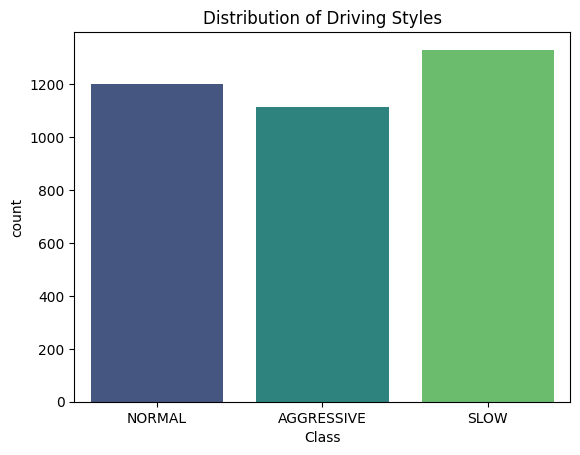

              AccX         AccY         AccZ        GyroX        GyroY  \
count  3644.000000  3644.000000  3644.000000  3644.000000  3644.000000   
mean      0.040467    -0.073418     0.008271     0.001593    -0.001273   
std       0.985653     0.903408     0.985061     0.066918     0.126205   
min      -4.636523    -4.699795    -7.143998    -0.751822    -1.587028   
25%      -0.550695    -0.592540    -0.558464    -0.028558    -0.053756   
50%       0.003931    -0.080833     0.002262     0.001985    -0.001833   
75%       0.595987     0.452401     0.556157     0.031918     0.051313   
max       4.985548     4.245151     5.171739     0.849255     1.679879   

             GyroZ     Timestamp  
count  3644.000000  3.644000e+03  
mean      0.007949  3.582707e+06  
std       0.115687  6.421479e+02  
min      -1.236468  3.581629e+06  
25%      -0.029398  3.582121e+06  
50%       0.002978  3.582702e+06  
75%       0.040852  3.583270e+06  
max       1.190500  3.583791e+06  


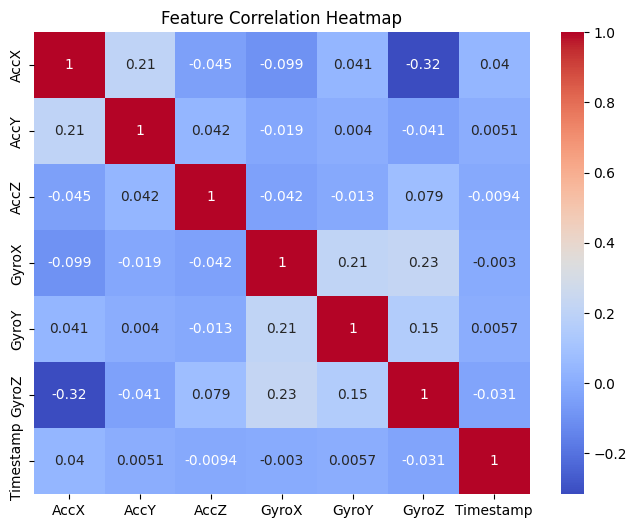

In [44]:
# Check for missing values
print("Missing values: \n", train_df.isnull().sum())

# Target Distribution
sns.countplot(x='Class', data=train_df, palette='viridis')
plt.title('Distribution of Driving Styles')
plt.show()

# Summary Statistics
print(train_df.describe())

# Correlation heatmap (use only numeric columns to avoid string -> float errors)
plt.figure(figsize=(8, 6))
numeric_df = train_df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

Feature Engineering

In [45]:
#Sort timestamp in ascending order
train_df = train_df.sort_values('Timestamp').reset_index(drop=True)
test_df = test_df.sort_values('Timestamp').reset_index(drop=True)

# Acceleration and Gyroscope Magnitudes
train_df['acc_magnitude'] = np.sqrt(train_df['AccX']**2 + train_df['AccY']**2 + train_df['AccZ']**2)
test_df['acc_magnitude'] = np.sqrt(test_df['AccX']**2 + test_df['AccY']**2 + test_df['AccZ']**2)

train_df['gyro_magnitude'] = np.sqrt(train_df['GyroX']**2 + train_df['GyroY']**2 + train_df['GyroZ']**2) 
test_df['gyro_magnitude'] = np.sqrt(test_df['GyroX']**2 + test_df['GyroY']**2 + test_df['GyroZ']**2)

# Rolling Statistics
for window in [3, 5, 7]:
    train_df[f'acc_mean_w{window}'] = train_df['acc_magnitude'].rolling(window=window).mean() 
    train_df[f'acc_std_w{window}'] = train_df['acc_magnitude'].rolling(window=window).std() 
    test_df[f'acc_mean_w{window}'] = test_df['acc_magnitude'].rolling(window=window).mean() 
    test_df[f'acc_std_w{window}'] = test_df['acc_magnitude'].rolling(window=window).std()
    
# Drop rows with NaN values generated by rolling calculations
train_df = train_df.dropna().reset_index(drop=True)
test_df = test_df.dropna().reset_index(drop=True)

# Jerk Calculation
train_df['jerk'] = np.gradient(train_df['acc_magnitude'], train_df['Timestamp']) 
test_df['jerk'] = np.gradient(test_df['acc_magnitude'], test_df['Timestamp'])

# Angular Velocity Change Rate
train_df['gyro_jerk'] = np.gradient(train_df['gyro_magnitude'], train_df['Timestamp']) 
test_df['gyro_jerk'] = np.gradient(test_df['gyro_magnitude'], test_df['Timestamp'])

# Check results
print("Feature engineering complete. New columns added:")
print([col for col in train_df.columns if col not in ['AccX','AccY','AccZ','GyroX','GyroY','GyroZ','Class','Timestamp']])

Feature engineering complete. New columns added:
['acc_magnitude', 'gyro_magnitude', 'acc_mean_w3', 'acc_std_w3', 'acc_mean_w5', 'acc_std_w5', 'acc_mean_w7', 'acc_std_w7', 'jerk', 'gyro_jerk']


Preprocessing

In [46]:
# Encode target labels
label_encoder = LabelEncoder()
train_df['Class_encoded'] = label_encoder.fit_transform(train_df['Class'])

# Feature and target split
feature_cols = [col for col in train_df.columns if col not in ['Class', 'Class_encoded', 'Timestamp']]
X = train_df[feature_cols]
y = train_df['Class_encoded']

# Split for validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Replace infinite values with NaN
for df in [X_train, X_val, test_df]:
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    numeric_cols = df.select_dtypes(include=['number']).columns
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
    
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
test_scaled = scaler.transform(test_df[feature_cols])
print("Data preprocessing complete.")

Data preprocessing complete.


Model Training and Evaluation

In [47]:
def evaluate_model(model, X_train, y_train, X_val, y_val):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    
    print("\nClassification Report:\n", classification_report(y_val, y_pred))
    print("Accuracy:", accuracy_score(y_val, y_pred))
    print("Precision:", precision_score(y_val, y_pred, average='weighted'))
    print("Recall:", recall_score(y_val, y_pred, average='weighted'))
    print("F1 Score:", f1_score(y_val, y_pred, average='weighted'))
    
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix - {model.__class__.__name__}')
    plt.show()

Try Baseline Models

Evaluating Logistic Regression...

Classification Report:
               precision    recall  f1-score   support

           0       0.52      0.61      0.56       223
           1       0.29      0.05      0.09       239
           2       0.45      0.71      0.55       266

    accuracy                           0.46       728
   macro avg       0.42      0.46      0.40       728
weighted avg       0.42      0.46      0.40       728

Accuracy: 0.4642857142857143
Precision: 0.41818016848138695
Recall: 0.4642857142857143
F1 Score: 0.40308720340540144


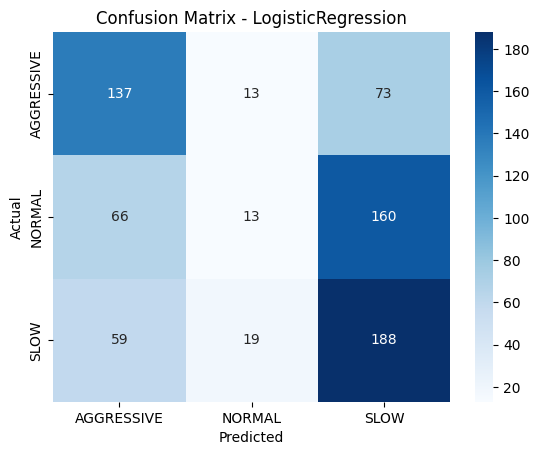

Evaluating Random Forest...

Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.57      0.57       223
           1       0.46      0.38      0.41       239
           2       0.50      0.57      0.53       266

    accuracy                           0.51       728
   macro avg       0.51      0.51      0.50       728
weighted avg       0.50      0.51      0.50       728

Accuracy: 0.5068681318681318
Precision: 0.5047297891783186
Recall: 0.5068681318681318
F1 Score: 0.5037610685414584


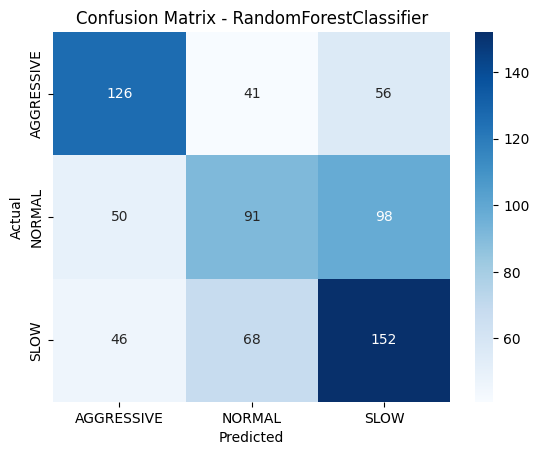

Evaluating Support Vector Machine...

Classification Report:
               precision    recall  f1-score   support

           0       0.59      0.53      0.56       223
           1       0.38      0.15      0.21       239
           2       0.45      0.74      0.56       266

    accuracy                           0.48       728
   macro avg       0.47      0.47      0.44       728
weighted avg       0.47      0.48      0.44       728

Accuracy: 0.4793956043956044
Precision: 0.4693574306212483
Recall: 0.4793956043956044
F1 Score: 0.444249933684469


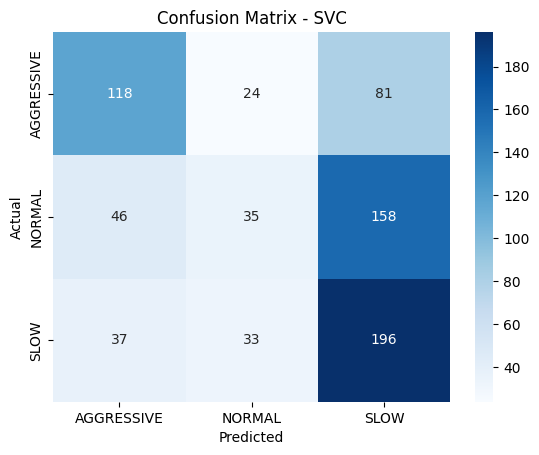

Evaluating XGBoost...

Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.48      0.52       223
           1       0.37      0.44      0.40       239
           2       0.45      0.44      0.45       266

    accuracy                           0.45       728
   macro avg       0.47      0.45      0.46       728
weighted avg       0.46      0.45      0.46       728

Accuracy: 0.4519230769230769
Precision: 0.464762298141419
Recall: 0.4519230769230769
F1 Score: 0.4556000986292495


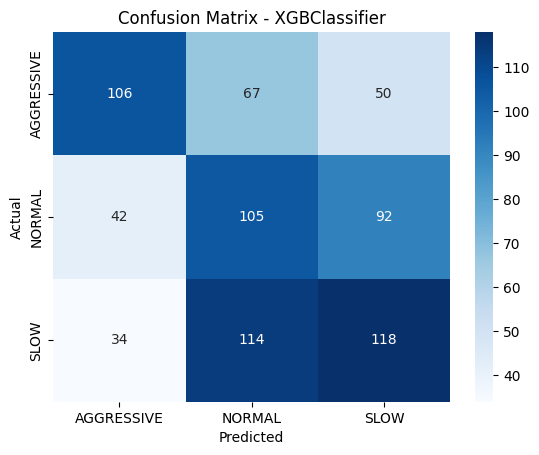

In [48]:
# Logistic Regression
print("Evaluating Logistic Regression...")
evaluate_model(LogisticRegression(max_iter=500), X_train_scaled, y_train, X_val_scaled, y_val)

# Random Forest
print("Evaluating Random Forest...")
evaluate_model(RandomForestClassifier(n_estimators=100, random_state=42), X_train_scaled, y_train, X_val_scaled, y_val)

# Support Vector Machine
print("Evaluating Support Vector Machine...")
evaluate_model(SVC(kernel='rbf', C=1, gamma='scale'), X_train_scaled, y_train, X_val_scaled, y_val)

# XGBoost
print("Evaluating XGBoost...")
evaluate_model(XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42), X_train_scaled, y_train, X_val_scaled, y_val)

Hyperparameter Tuning

Tuning Logistic Regression...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best parameters for Logistic Regression: {'C': 1, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'lbfgs'}
Tuning Random Forest...
Fitting 3 folds for each of 405 candidates, totalling 1215 fits
Best parameters for Random Forest: {'class_weight': 'balanced', 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Tuning Support Vector Machine...
Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best parameters for Support Vector Machine: {'C': 1, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'rbf'}
Tuning XGBoost...
Fitting 3 folds for each of 100 candidates, totalling 300 fits
Best parameters for XGBoost: {'colsample_bytree': np.float64(0.9072342412944678), 'learning_rate': np.float64(0.05737095495467999), 'max_depth': 6, 'min_child_weight': 3, 'n_estimators': 300, 'reg_alpha': 0.1, 'reg_lambda': 1, 'subsample': np

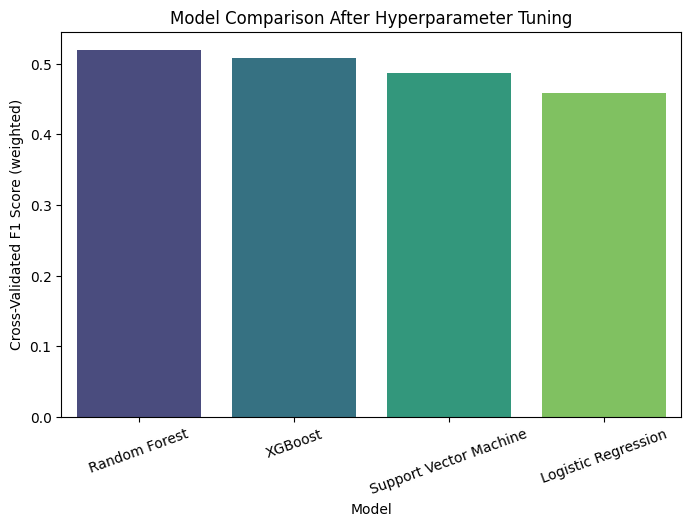

Best model after tuning: Random Forest

Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.58      0.58       223
           1       0.44      0.37      0.40       239
           2       0.52      0.59      0.55       266

    accuracy                           0.51       728
   macro avg       0.51      0.51      0.51       728
weighted avg       0.51      0.51      0.51       728

Accuracy: 0.5137362637362637
Precision: 0.5091566854693951
Recall: 0.5137362637362637
F1 Score: 0.5097162358646458


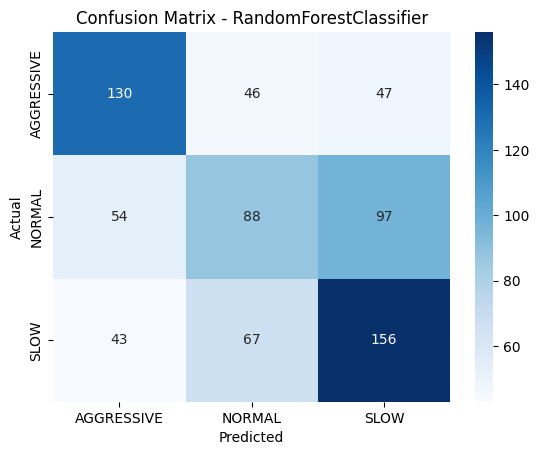

In [ ]:
tuned_models = {}
results_summary = []

# Logistic Regression
print("Tuning Logistic Regression...")
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear'],
    'penalty': ['l2'],
    'class_weight': ['balanced']
}
lr = LogisticRegression(max_iter=500, random_state=42)
grid_lr = GridSearchCV(lr, param_grid_lr, cv=3, scoring='f1_weighted', n_jobs=-1, verbose=1)
grid_lr.fit(X_train_scaled, y_train)

tuned_models['Logistic Regression'] = grid_lr.best_estimator_
results_summary.append(['Logistic Regression', grid_lr.best_score_, grid_lr.best_params_])
print("Best parameters for Logistic Regression:", grid_lr.best_params_)

# Random Forest
print("Tuning Random Forest...")
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10],
    'class_weight' : ['balanced'],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 0.5]
}
rf = RandomForestClassifier(random_state=42)
grid_rf = GridSearchCV(rf, param_grid_rf, cv=3, scoring='f1_weighted', n_jobs=-1, verbose=1)
grid_rf.fit(X_train_scaled, y_train)

tuned_models['Random Forest'] = grid_rf.best_estimator_
results_summary.append(['Random Forest', grid_rf.best_score_, grid_rf.best_params_])
print("Best parameters for Random Forest:", grid_rf.best_params_)

# Support Vector Machine
print("Tuning Support Vector Machine...")
param_grid_svm = {
    'C': [0.1, 1, 10, 50, 100],
    'gamma': [0.001, 0.01, 0.1, 'scale', 'auto'],
    'kernel': ['rbf', 'poly'],
    'class_weight': ['balanced']
}
svm_model = SVC(probability=True, random_state=42)
grid_svm = GridSearchCV(svm_model, param_grid_svm, cv=3, scoring='f1_weighted', n_jobs=-1, verbose=1)
grid_svm.fit(X_train_scaled, y_train)

tuned_models['Support Vector Machine'] = grid_svm.best_estimator_
results_summary.append(['Support Vector Machine', grid_svm.best_score_, grid_svm.best_params_])
print("Best parameters for Support Vector Machine:", grid_svm.best_params_)

# XGBoost
print("Tuning XGBoost...")
param_dist_xgb = {
    'learning_rate': stats.uniform(0.001, 0.2),
    'max_depth': [3, 4, 5, 6, 8],
    'n_estimators': [300, 500, 800],
    'subsample': stats.uniform(0.5, 0.5),
    'colsample_bytree': stats.uniform(0.5, 0.5),
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 2, 5],
    'min_child_weight': [1, 3, 5]
}
xgb = XGBClassifier(eval_metric='mlogloss', random_state=42)
random_search = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist_xgb,
    n_iter=100,2
    scoring='f1_weighted',
    cv=3,
    n_jobs=-1,
    verbose=1,
    random_state=42
)
random_search.fit(X_train_scaled, y_train)

tuned_models['XGBoost'] = random_search.best_estimator_
results_summary.append(['XGBoost', random_search.best_score_, random_search.best_params_])
print("Best parameters for XGBoost:", random_search.best_params_)

# Compare tuned model results
results_df = pd.DataFrame(results_summary, columns=['Model', 'CV F1 (weighted)', 'Best Params'])
results_df = results_df.sort_values(by='CV F1 (weighted)', ascending=False)
print("\nTuned Model Comparison:\n", results_df)

# Plot comparison
plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='CV F1 (weighted)', data=results_df, palette='viridis')
plt.title('Model Comparison After Hyperparameter Tuning')
plt.ylabel('Cross-Validated F1 Score (weighted)')
plt.xticks(rotation=20)
plt.show()

best_model_name = results_df.iloc[0]['Model']
best_model = tuned_models[best_model_name]
print(f"Best model after tuning: {best_model_name}")
evaluate_model(best_model, X_train_scaled, y_train, X_val_scaled, y_val)

Create Slide Window Sequences

In [50]:
def create_sliding_windows(features, labels=None, window_size=20):
    """
    Convert features (and labels) into sliding windows of size `window_size`.
    If labels are provided, the label for each window is set to the label of the
    final timestep in that window.
    """
    X_seq = []
    y_seq = []

    for i in range(len(features) - window_size):
        window = features[i:i+window_size]
        X_seq.append(window)

        if labels is not None:
            window_label = labels[i + window_size - 1]
            y_seq.append(window_label)

    X_seq = np.array(X_seq)
    
    if labels is None:
        return X_seq
    
    return X_seq, np.array(y_seq)

# Create sequences for train/validation
window_size = 50

X_train_seq, y_train_seq = create_sliding_windows(X_train_scaled, y_train.values, window_size)
X_val_seq, y_val_seq     = create_sliding_windows(X_val_scaled, y_val.values, window_size)

# Create sequences for test set (labels=None)
test_seq = create_sliding_windows(test_scaled, labels=None, window_size=window_size)

print("Sequence data created:")
print("X_train_seq:", X_train_seq.shape)
print("X_val_seq:  ", X_val_seq.shape)

Sequence data created:
X_train_seq: (2860, 50, 16)
X_val_seq:   (678, 50, 16)


Build LSTM Model

In [51]:
# Number of output classes
num_classes = len(np.unique(y_train))

# Convert labels to one-hot encoding
y_train_cat = to_categorical(y_train_seq, num_classes)
y_val_cat = to_categorical(y_val_seq, num_classes)

# LSTM model architecture
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(window_size, X_train_scaled.shape[1])),
    Dropout(0.3),
    LSTM(128),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

lstm_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

lstm_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 50, 64)         │        20,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 119,939 (468.51 KB)

 Trainable params: 119,939 (468.51 KB)

 Non-trainable params: 0 (0.00 B)

Train LSTM Model

In [52]:
history = lstm_model.fit(
    X_train_seq, y_train_cat,
    validation_data=(X_val_seq, y_val_cat),
    epochs=50,
    batch_size=64,
    verbose=1,
    callbacks=[early_stop]
)

Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.3471 - loss: 1.0967 - val_accuracy: 0.4027 - val_loss: 1.0890
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.4201 - loss: 1.0795 - val_accuracy: 0.4027 - val_loss: 1.0866
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.4184 - loss: 1.0732 - val_accuracy: 0.4071 - val_loss: 1.0801
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.4262 - loss: 1.0620 - val_accuracy: 0.4248 - val_loss: 1.0727
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.4494 - loss: 1.0446 - val_accuracy: 0.4425 - val_loss: 1.0482
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.4538 - loss: 1.0248 - val_accuracy: 0.4454 - val_loss: 1.0375
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.5151 - loss: 0.9794 - val_accuracy: 0.4558 - val_loss: 1.0317
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.4852 - loss: 0.9978 - val_accuracy: 0.4425 - v

Evaluate LSTM Performance

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
LSTM Classification Report
              precision    recall  f1-score   support

  AGGRESSIVE       0.52      0.55      0.54       212
      NORMAL       0.37      0.11      0.16       219
        SLOW       0.44      0.69      0.54       247

    accuracy                           0.46       678
   macro avg       0.44      0.45      0.41       678
weighted avg       0.44      0.46      0.42       678



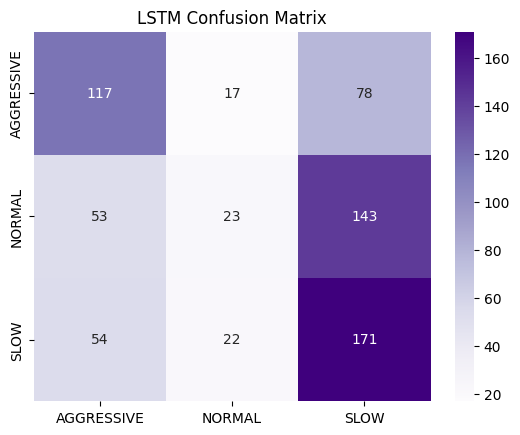

In [53]:
# Predict on validation sequences
val_probs = lstm_model.predict(X_val_seq)
val_preds = np.argmax(val_probs, axis=1)

print("LSTM Classification Report")
print(classification_report(
    y_val_seq,
    val_preds,
    target_names=label_encoder.classes_
))

cm = confusion_matrix(y_val_seq, val_preds)
sns.heatmap(
    cm, annot=True, fmt='d',
    cmap='Purples',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("LSTM Confusion Matrix")
plt.show()


Generate Test Predictions using LSTM

In [54]:
test_probs = lstm_model.predict(test_seq)
test_preds = np.argmax(test_probs, axis=1)

test_labels = label_encoder.inverse_transform(test_preds)

submission_lstm = pd.DataFrame({
    'Timestamp': test_df['Timestamp'].iloc[window_size:].values,
    'predicted_driving_style': test_labels
})

submission_lstm.to_csv('../results/test_predictions_lstm.csv', index=False)
print("Predictions saved to ../results/test_predictions_lstm.csv")

95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Predictions saved to ../results/test_predictions_lstm.csv


Predict on Test Data

In [55]:
# Predict with best model
test_predictions = best_model.predict(test_scaled)
test_labels = label_encoder.inverse_transform(test_predictions)

# Save predictions
submission = pd.DataFrame({'timestamp': test_df['Timestamp'], 'predicted_driving_style': test_labels})
submission.to_csv('../results/test_predictions.csv', index=False)
print("Predictions saved to ../results/test_predictions.csv")

# Save model and scaler
joblib.dump(best_model, '../results/best_driving_behavior_model.pkl')
joblib.dump(scaler, '../results/scaler.pkl')
joblib.dump(label_encoder, '../results/label_encoder.pkl')
print("Model, scaler, and label encoder saved.")



Predictions saved to ../results/test_predictions.csv
Model, scaler, and label encoder saved.
